# Sort spot clean playground

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import skimage.filters as flt
import sys

sys.path.append('../../build-imagingsuite/Release/lib/')
import imgalg as ia

sys.path.append('../../scripts/python')
import amglib.readers as rd


In [66]:
ss = ia.SortSpotClean(True,16,False)

In [234]:
#img = rd.read_image('/Users/Shared/Data/P20241355_stepwedge/02_rawdata/01_data/h2o_5s_00003.fits')
img= rd.read_image('../../TestData/2D/tiff/spots/balls.tif')
#img= rd.read_image('../../TestData/2D/tiff/manyspots.tif')


In [235]:
img2 = np.copy(img).astype('float32')

In [236]:
ss.process(img2,quantile=0.95,th=5,method=ia.eSortSpotQuantile.SortQuantileBright)

Processing 2D image with dimensions:  [1024, 512]


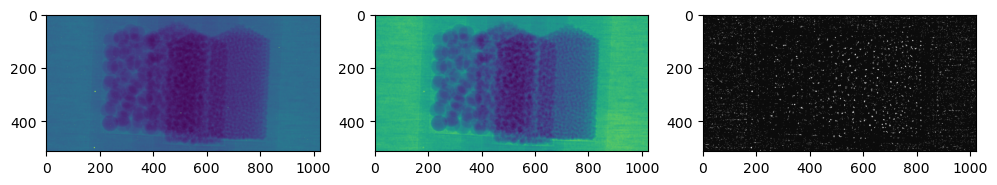

In [237]:
fig,ax = plt.subplots(1,3,figsize=[12,4])
ax[0].imshow(img)
ax[1].imshow(img2)
ax[2].imshow(img-img2,vmin=-1,vmax=20,cmap='gray')

In [238]:
1126*0.44

495.44

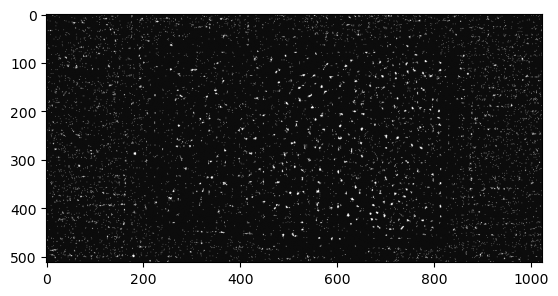

In [239]:
plt.imshow(img-img2,vmin=-1,vmax=20,cmap='gray')

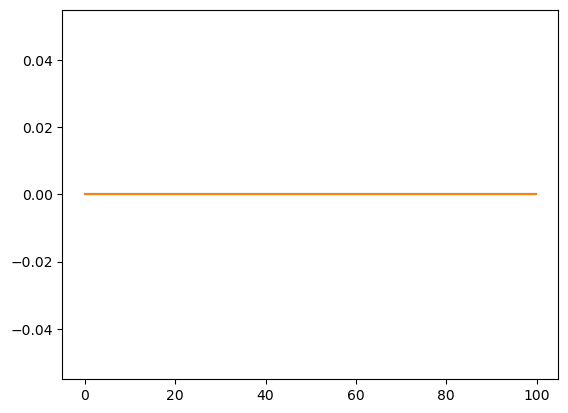

In [240]:
h0=np.histogram(img.ravel(),bins=np.linspace(0,100,512));
h1=np.histogram(img2.ravel(),bins=np.linspace(0,100,512));

plt.plot(h0[1][:-1],h0[0])
plt.plot(h1[1][:-1],h1[0])

# plt.semilogy(h0[1][:-1],h0[0]-h1[0])


In [241]:
mimg = flt.median(img, footprint=np.ones([7,7]))

In [242]:
diff = img-img2

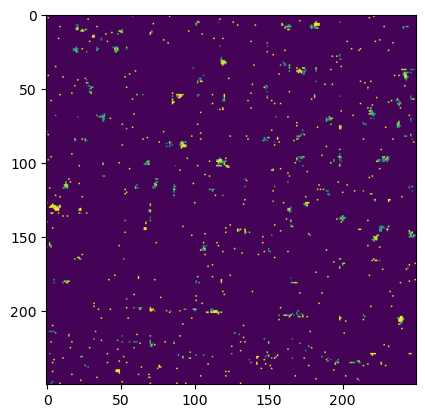

In [243]:
plt.imshow(diff[250:500,250:500],vmin=-10,vmax=1000)

In [244]:
sst = ia.SortSpotClean(True,24, True)

Processing 2D image with dimensions:  [1024, 512]


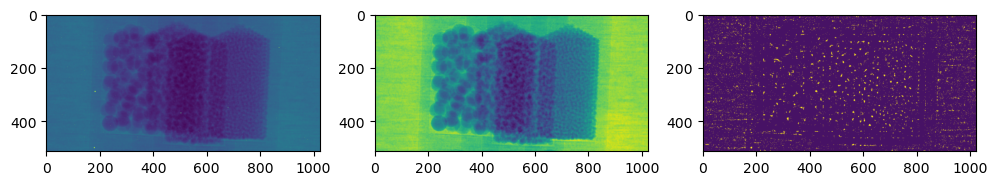

In [245]:
img3 = np.copy(img).astype('float32')
sst.process(img3,quantile=0.95,th=3,method=ia.eSortSpotQuantile.SortQuantileBright)

fig,ax = plt.subplots(1,3,figsize=[12,4])
ax[0].imshow(img)
ax[1].imshow(img3)
ax[2].imshow(img-img3,vmin=-1,vmax=20)

np.float32(2.8952162e+07)

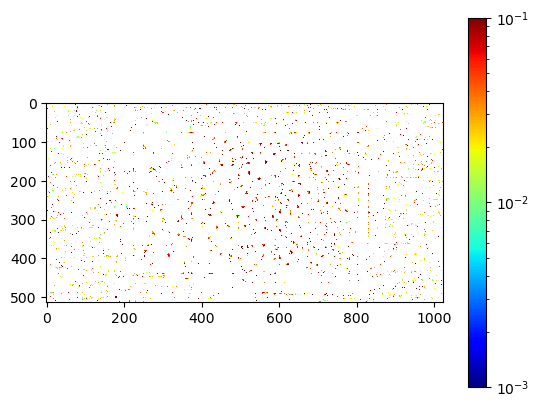

In [246]:
d=img-img3

# [vmin,vmax]=np.quantile(d.ravel(),[0.01,0.99])
# plt.imshow(d,vmin=vmin,vmax=vmax)
a=plt.imshow(np.abs(d)/img3, norm = LogNorm(vmin=0.001,vmax=0.1),cmap='jet',interpolation='None')
plt.colorbar(a)
d.sum()

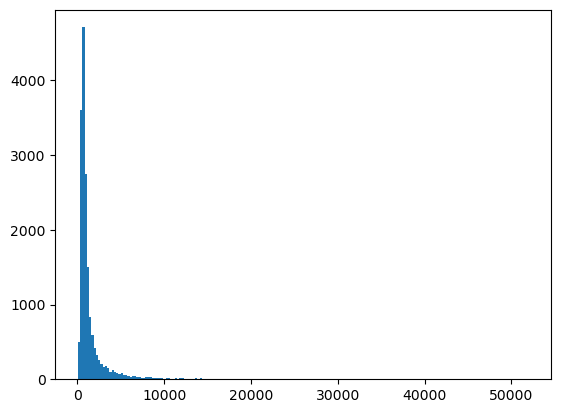

In [247]:
plt.hist(d[0<d].ravel(),bins=200);

Text(0, 0.5, 'Cleaned image')

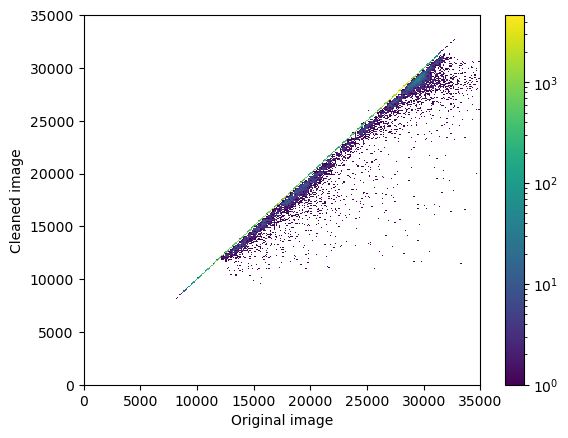

In [269]:

a=plt.hist2d(img.ravel(),img3.ravel(),bins=512,norm=LogNorm());
plt.colorbar()
lim_min=0
lim_max=35000
plt.gca().set_xlim(lim_min,lim_max)
plt.gca().set_ylim(lim_min,lim_max)
plt.xlabel('Original image')
plt.ylabel('Cleaned image')

In [270]:
ss.process(img2,quantile=0.95,th=5,method=ia.eSortSpotQuantile.SortQuantileBright)

Processing 2D image with dimensions:  [1024, 512]


In [271]:
sst.process(img3,quantile=0.95,th=5,method=ia.eSortSpotQuantile.SortQuantileBright)

Processing 2D image with dimensions:  [1024, 512]


In [272]:
mimg = flt.median(img,footprint=np.ones([3,3]))

Text(0, 0.5, 'Cleaned image')

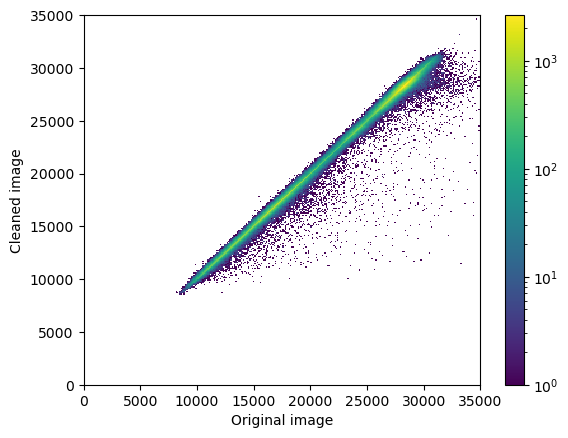

In [273]:
a=plt.hist2d(img.ravel(),mimg.ravel(),bins=512,norm=LogNorm());
plt.colorbar()
# lim_min=0
# lim_max=5000
plt.gca().set_xlim(lim_min,lim_max)
plt.gca().set_ylim(lim_min,lim_max)
plt.xlabel('Original image')
plt.ylabel('Cleaned image')

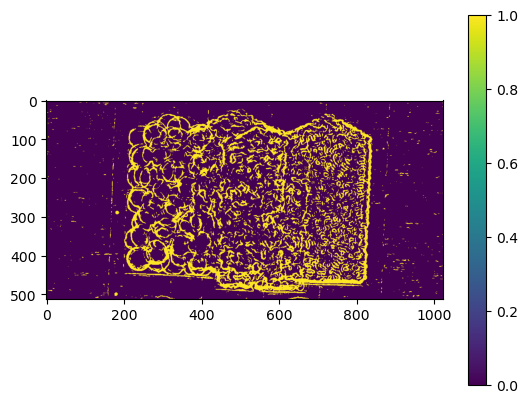

In [285]:
gradient = flt.prewitt(flt.median(img,footprint=np.ones([5,5])))
th = 500
plt.imshow(th<gradient)
plt.colorbar()

In [290]:
mask=th<gradient
proc = img3
samples = np.column_stack((img[mask].ravel(),proc[mask].ravel(), gradient[mask].ravel()))
H, edges = np.histogramdd(
    samples,
    bins=(200, 200, 200),                # number of bins per dimension
    range=[(lim_min, lim_max), (lim_min, lim_max), (0, 5000)] # optional limits
)

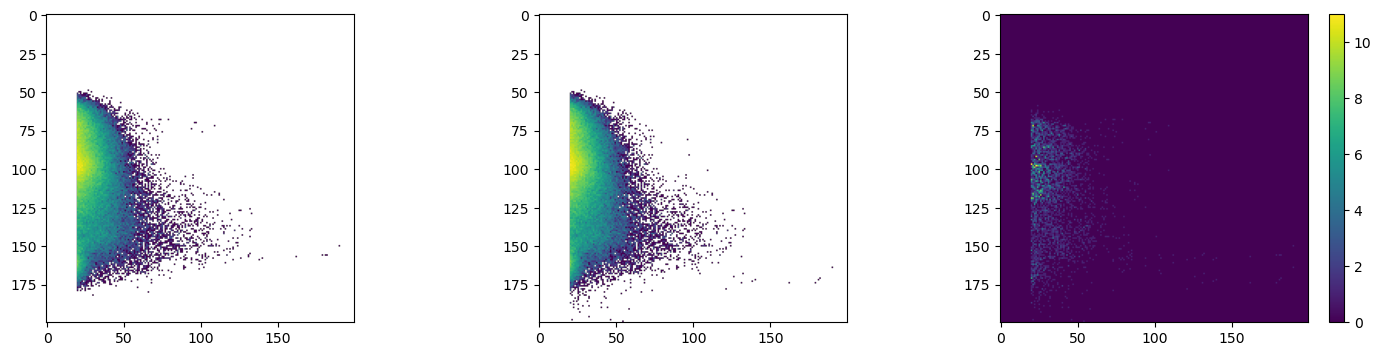

In [291]:
fig,ax = plt.subplots(1,3,figsize=(18,4))
ax[0].imshow(H.sum(axis=0),norm=LogNorm())
ax[1].imshow(H.sum(axis=1),norm=LogNorm())
a=ax[2].imshow(np.abs(H.sum(axis=0)-H.sum(axis=1)))#,norm=LogNorm())
fig.colorbar(a,ax=ax[2])

In [292]:
mask2=gradient<th
samples = np.column_stack((img[mask2].ravel(),proc[mask2].ravel(), gradient[mask2].ravel()))
H, edges = np.histogramdd(
    samples,
    bins=(200, 200, 200),                # number of bins per dimension
    range=[(lim_min, lim_max), (lim_min, lim_max), (0, th)] # optional limits
)

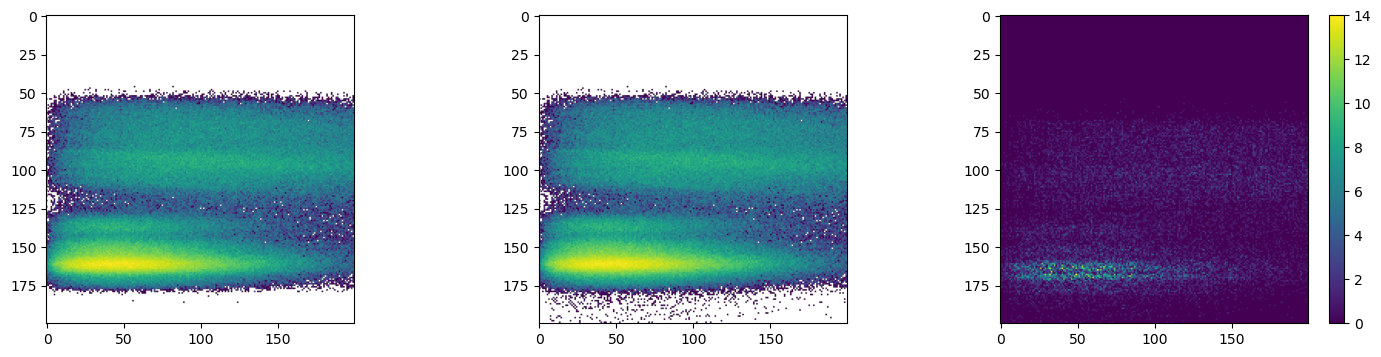

In [293]:
fig,ax = plt.subplots(1,3,figsize=(18,4))
ax[0].imshow(H.sum(axis=0),norm=LogNorm())
ax[1].imshow(H.sum(axis=1),norm=LogNorm())
a=ax[2].imshow(np.abs(H.sum(axis=0)-H.sum(axis=1))) #/np.sum(mask2),norm=LogNorm())
fig.colorbar(a,ax=ax[2])

In [220]:
mask.sum()/np.prod(mask.shape)

np.float64(0.29165196418762207)

# Process 3D

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import skimage.filters as flt
import sys

sys.path.append('../../build-imagingsuite/Release/lib/')
import imgalg as ia

sys.path.append('../../scripts/python')
import amglib.readers as rd

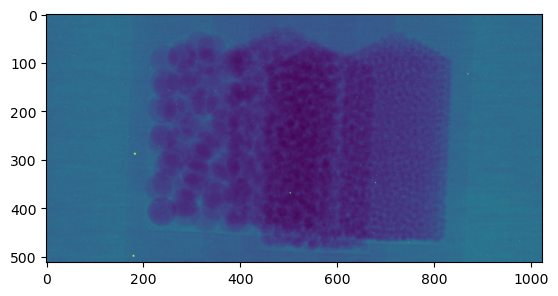

In [25]:
#img = rd.read_image('/Users/Shared/Data/P20241355_stepwedge/02_rawdata/01_data/h2o_5s_00003.fits')
img= rd.read_image('../../TestData/2D/tiff/spots/balls.tif').astype('float32')
#img= rd.read_image('../../TestData/2D/tiff/manyspots.tif')
plt.imshow(img)

In [31]:
ss  = ia.SortSpotClean(True,32,False)
sst = ia.SortSpotClean(True,32,True)

In [32]:
# Prepare 3D image
N=200

N0 = img.shape[0] // N
N1 = img.shape[1] // N

vol = np.zeros([N0*N1,N,N],dtype='float32')

i = 0
for r in range(N0) :
    for c in range(N1) :
        vol[i]=img[(r*N):(r*N+N),(c*N):(c*N+N)]
        i=i+1
        
print(vol.shape)

(10, 200, 200)


In [33]:
vol2D=vol.copy()

for i in range(vol.shape[0]) :
    tmp = vol2D[i]
    sst.process(tmp,quantile=0.95,th=5,method=ia.eSortSpotQuantile.SortQuantileBright)
    vol2D[i] = tmp

Processing 2D image with dimensions:  [200, 200]
Processing 2D image with dimensions:  [200, 200]
Processing 2D image with dimensions:  [200, 200]
Processing 2D image with dimensions:  [200, 200]
Processing 2D image with dimensions:  [200, 200]
Processing 2D image with dimensions:  [200, 200]
Processing 2D image with dimensions:  [200, 200]
Processing 2D image with dimensions:  [200, 200]
Processing 2D image with dimensions:  [200, 200]
Processing 2D image with dimensions:  [200, 200]


In [43]:
vol3D=vol.copy()

sst.process(vol3D,quantile=0.98,th=2,method=ia.eSortSpotQuantile.SortQuantileBright)

Processing 3D image with dimensions:  [200, 200, 10]


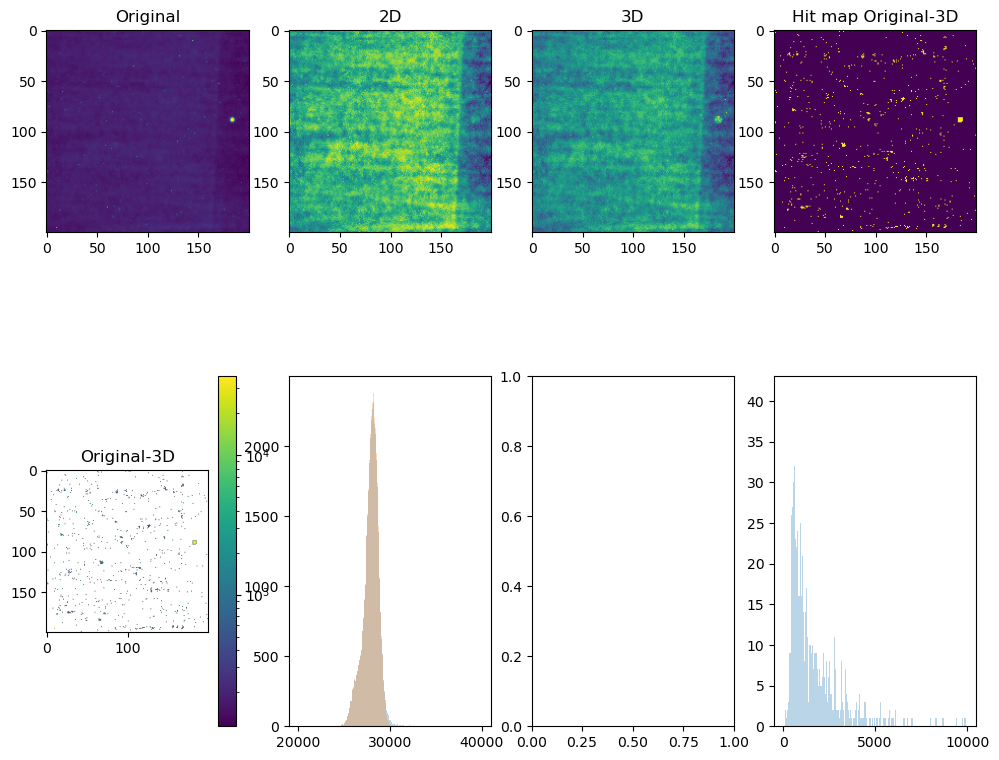

In [56]:
fig,ax = plt.subplots(2,4,figsize=(12,10))
ax=ax.ravel()
idx = 5
ax[0].imshow(vol[idx])
ax[0].set_title(f'Original')

ax[1].imshow(vol2D[idx])
ax[1].set_title('2D')

ax[2].imshow(vol3D[idx])
ax[2].set_title('3D')

ax[3].imshow(0<(vol[idx]-vol3D[idx]))
ax[3].set_title('Hit map Original-3D')

a=ax[4].imshow(vol[idx]-vol3D[idx], norm=LogNorm())
fig.colorbar(a,ax=ax[4])
ax[4].set_title('Original-3D')

ax[5].hist(vol[idx].ravel(),bins=np.linspace(20000,40000,200),alpha=0.3);
ax[5].hist(vol3D[idx].ravel(),bins=np.linspace(20000,40000,200),alpha=0.3);
ax[7].hist((vol[idx]-vol3D[idx]).ravel(),bins=np.linspace(10,10000,200),alpha=0.3);


In [57]:
0.2*1126/60

3.7533333333333334